In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import scienceplots 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import seaborn as sns

plt.style.use('science')
plt.style.use('nature')

## Cora

In [22]:
cora_sn = pd.read_csv('corrsi\\cora_gcn_vae_sn_lp_test.csv')
cora_sn.columns

Index(['nodes_num', 'measure', 'sparsity', 'diff_sparsity', 'avg_degree',
       'diff_degree', 'avg_cluster', 'diff_cluster', 'avg_spl', 'diff_spl',
       'coeff_diff', 'r_C', 'r_L', 'alpha', 'mean_auc', 'std_auc', 'mean_ap',
       'std_ap', 'mean_time', 'std_time'],
      dtype='object')

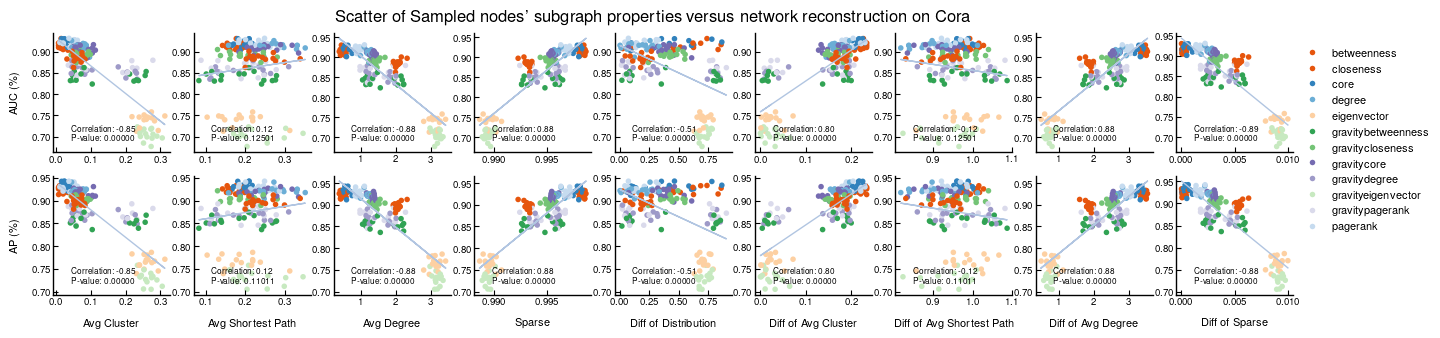

In [23]:
cora_sn = pd.read_csv('corrsi\\cora_gcn_vae_sn_lp_test.csv')
avg_cluster = cora_sn['avg_cluster']
avg_path = cora_sn['avg_spl']
avg_degree =  cora_sn['avg_degree']
sparse = cora_sn['sparsity']
avg_cluster_diff = cora_sn['diff_cluster']
avg_path_diff = cora_sn['diff_spl']
avg_degree_diff =  cora_sn['diff_degree']
sparse_diff = cora_sn['diff_sparsity']


diff = cora_sn['coeff_diff']
labels = cora_sn['measure']
AUC= cora_sn['mean_auc']
AP= cora_sn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on Cora",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cora_sn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cora_sn_corr.pdf',dpi=100)

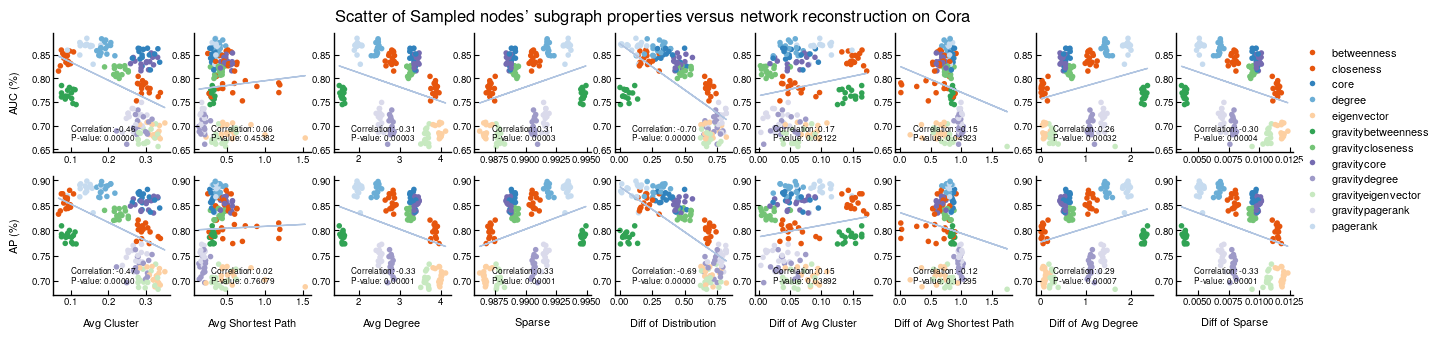

In [24]:
cora_tn = pd.read_csv('corrsi\\cora_gcn_vae_tn_lp_test.csv')
avg_cluster = cora_tn['avg_cluster']
avg_path = cora_tn['avg_spl']
avg_degree =  cora_tn['avg_degree']
sparse = cora_tn['sparsity']
avg_cluster_diff = cora_tn['diff_cluster']
avg_path_diff = cora_tn['diff_spl']
avg_degree_diff =  cora_tn['diff_degree']
sparse_diff = cora_tn['diff_sparsity']


diff = cora_tn['coeff_diff']
labels = cora_tn['measure']
AUC= cora_tn['mean_auc']
AP= cora_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on Cora",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cora_tn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cora_tn_corr.pdf',dpi=100)

## Citeseer


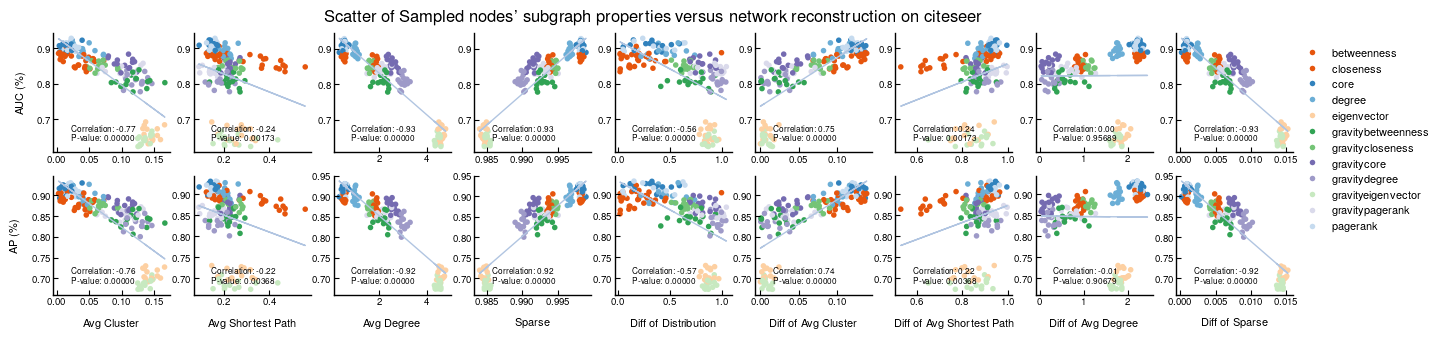

In [25]:
citeseer_sn = pd.read_csv('corrsi\\citeseer_gcn_vae_sn_lp_test.csv')
avg_cluster = citeseer_sn['avg_cluster']
avg_path = citeseer_sn['avg_spl']
avg_degree =  citeseer_sn['avg_degree']
sparse = citeseer_sn['sparsity']
avg_cluster_diff = citeseer_sn['diff_cluster']
avg_path_diff = citeseer_sn['diff_spl']
avg_degree_diff =  citeseer_sn['diff_degree']
sparse_diff = citeseer_sn['diff_sparsity']


diff = citeseer_sn['coeff_diff']
labels = citeseer_sn['measure']
AUC= citeseer_sn['mean_auc']
AP= citeseer_sn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on citeseer",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\citeseer_sn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\citeseer_sn_corr.pdf',dpi=100)

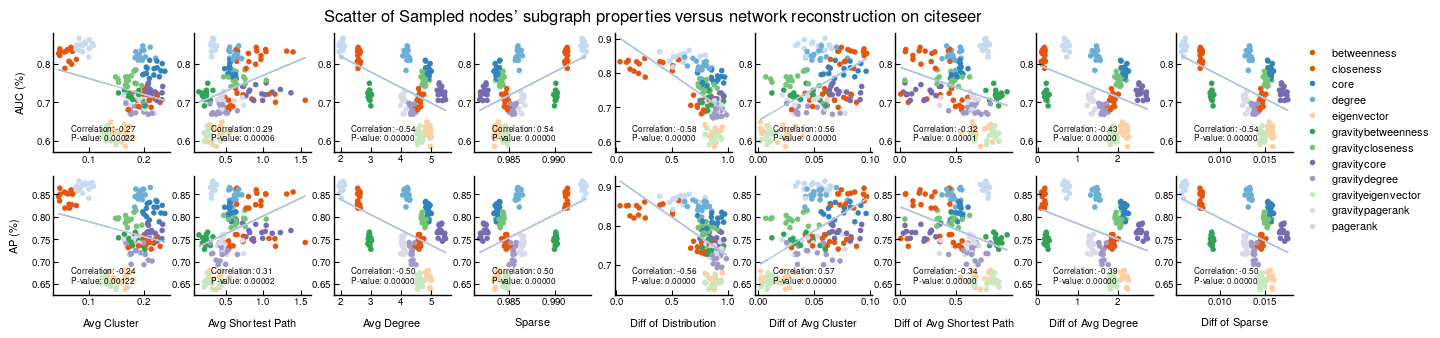

In [26]:
citeseer_tn = pd.read_csv('corrsi\\citeseer_gcn_vae_tn_lp_test.csv')
avg_cluster = citeseer_tn['avg_cluster']
avg_path = citeseer_tn['avg_spl']
avg_degree =  citeseer_tn['avg_degree']
sparse = citeseer_tn['sparsity']
avg_cluster_diff = citeseer_tn['diff_cluster']
avg_path_diff = citeseer_tn['diff_spl']
avg_degree_diff =  citeseer_tn['diff_degree']
sparse_diff = citeseer_tn['diff_sparsity']


diff = citeseer_tn['coeff_diff']
labels = citeseer_tn['measure']
AUC= citeseer_tn['mean_auc']
AP= citeseer_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on citeseer",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\citeseer_tn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\citeseer_tn_corr.pdf',dpi=100)

## Pubmed

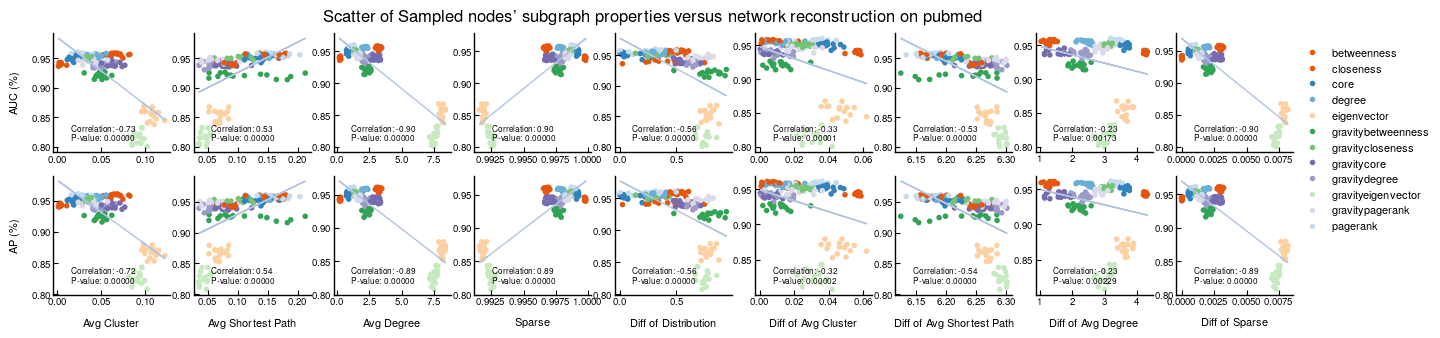

In [27]:
pubmed_sn = pd.read_csv('corrsi\\pubmed_gcn_vae_sn_lp_test.csv')
avg_cluster = pubmed_sn['avg_cluster']
avg_path = pubmed_sn['avg_spl']
avg_degree =  pubmed_sn['avg_degree']
sparse = pubmed_sn['sparsity']
avg_cluster_diff = pubmed_sn['diff_cluster']
avg_path_diff = pubmed_sn['diff_spl']
avg_degree_diff =  pubmed_sn['diff_degree']
sparse_diff = pubmed_sn['diff_sparsity']


diff = pubmed_sn['coeff_diff']
labels = pubmed_sn['measure']
AUC= pubmed_sn['mean_auc']
AP= pubmed_sn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on pubmed",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\pubmed_sn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\pubmed_sn_corr.pdf',dpi=100)

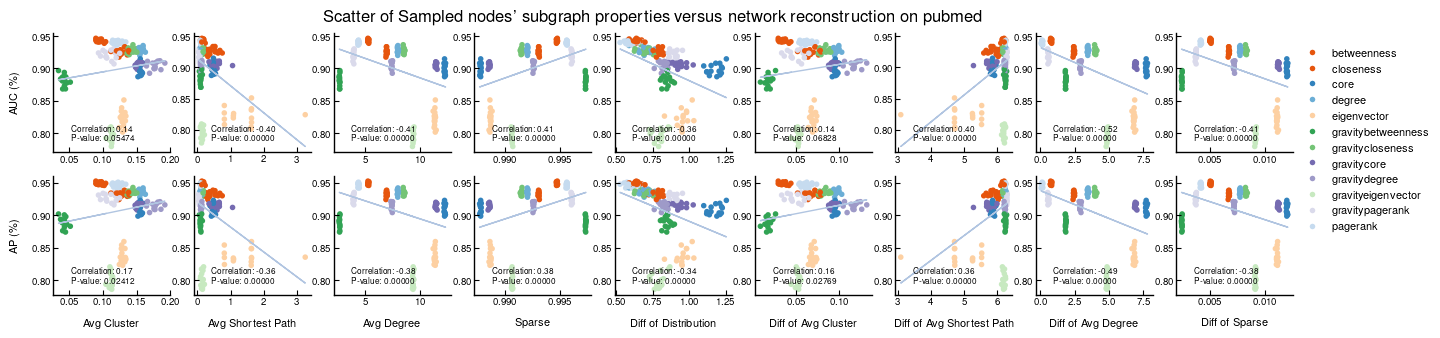

In [28]:
pubmed_tn = pd.read_csv('corrsi\\pubmed_gcn_vae_tn_lp_test.csv')
avg_cluster = pubmed_tn['avg_cluster']
avg_path = pubmed_tn['avg_spl']
avg_degree =  pubmed_tn['avg_degree']
sparse = pubmed_tn['sparsity']
avg_cluster_diff = pubmed_tn['diff_cluster']
avg_path_diff = pubmed_tn['diff_spl']
avg_degree_diff =  pubmed_tn['diff_degree']
sparse_diff = pubmed_tn['diff_sparsity']


diff = pubmed_tn['coeff_diff']
labels = pubmed_tn['measure']
AUC= pubmed_tn['mean_auc']
AP= pubmed_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on pubmed",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\pubmed_tn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\pubmed_tn_corr.pdf',dpi=100)

## CA-CondMat

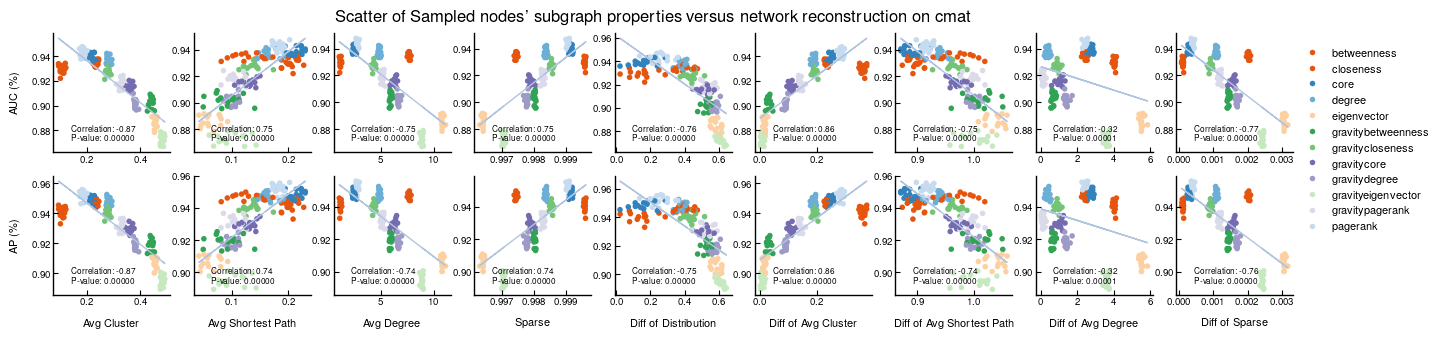

In [29]:
cmat_sn = pd.read_csv('corrsi\\cmat_gcn_vae_sn_lp_test.csv')
avg_cluster = cmat_sn['avg_cluster']
avg_path = cmat_sn['avg_spl']
avg_degree =  cmat_sn['avg_degree']
sparse = cmat_sn['sparsity']
avg_cluster_diff = cmat_sn['diff_cluster']
avg_path_diff = cmat_sn['diff_spl']
avg_degree_diff =  cmat_sn['diff_degree']
sparse_diff = cmat_sn['diff_sparsity']


diff = cmat_sn['coeff_diff']
labels = cmat_sn['measure']
AUC= cmat_sn['mean_auc']
AP= cmat_sn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on cmat",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cmat_sn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cmat_sn_corr.pdf',dpi=100)

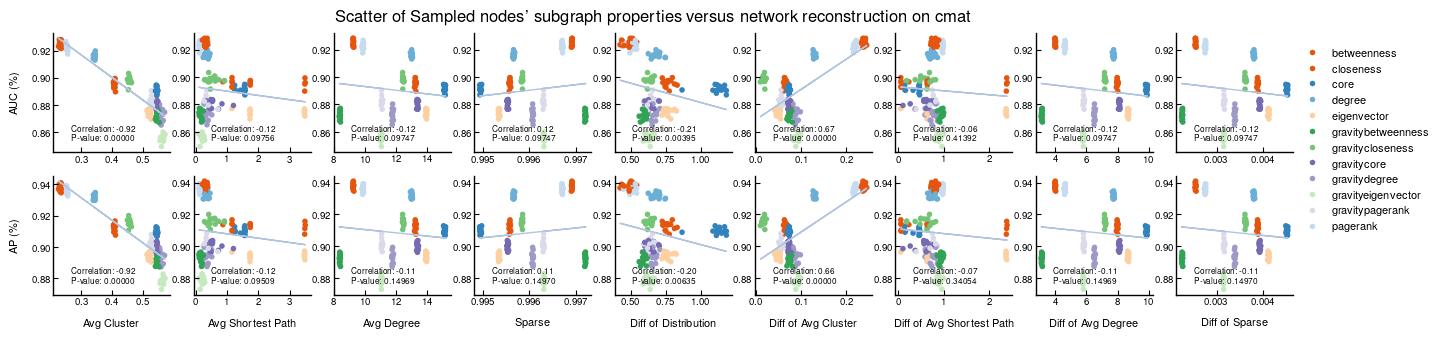

In [30]:
cmat_tn = pd.read_csv('corrsi\\cmat_gcn_vae_tn_lp_test.csv')
avg_cluster = cmat_tn['avg_cluster']
avg_path = cmat_tn['avg_spl']
avg_degree =  cmat_tn['avg_degree']
sparse = cmat_tn['sparsity']
avg_cluster_diff = cmat_tn['diff_cluster']
avg_path_diff = cmat_tn['diff_spl']
avg_degree_diff =  cmat_tn['diff_degree']
sparse_diff = cmat_tn['diff_sparsity']


diff = cmat_tn['coeff_diff']
labels = cmat_tn['measure']
AUC= cmat_tn['mean_auc']
AP= cmat_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on cmat",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cmat_tn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cmat_tn_corr.pdf',dpi=100)

## brainfly

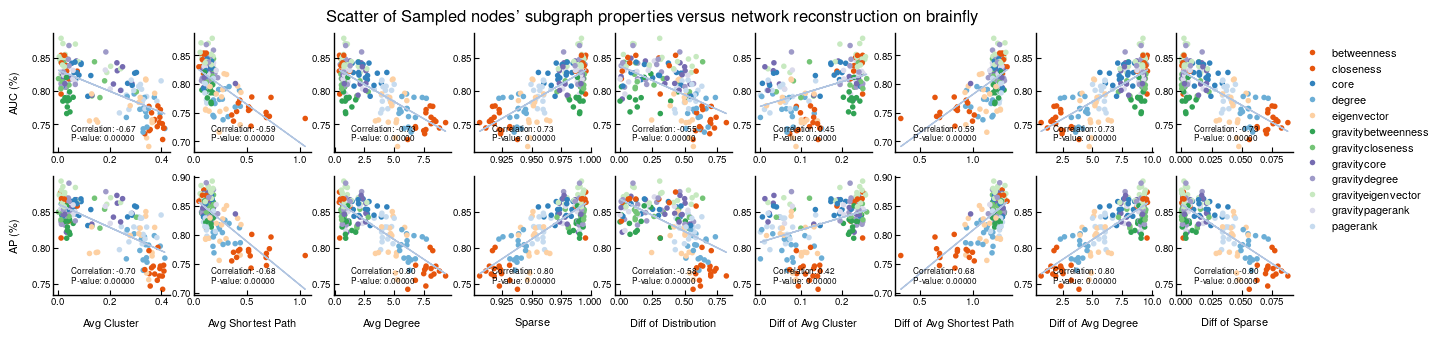

In [31]:
brainfly_sn = pd.read_csv('corrsi\\brainfly_gcn_vae_sn_lp_test.csv')
avg_cluster = brainfly_sn['avg_cluster']
avg_path = brainfly_sn['avg_spl']
avg_degree =  brainfly_sn['avg_degree']
sparse = brainfly_sn['sparsity']
avg_cluster_diff = brainfly_sn['diff_cluster']
avg_path_diff = brainfly_sn['diff_spl']
avg_degree_diff =  brainfly_sn['diff_degree']
sparse_diff = brainfly_sn['diff_sparsity']


diff = brainfly_sn['coeff_diff']
labels = brainfly_sn['measure']
AUC= brainfly_sn['mean_auc']
AP= brainfly_sn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on brainfly",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\brainfly_sn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\brainfly_sn_corr.pdf',dpi=100)

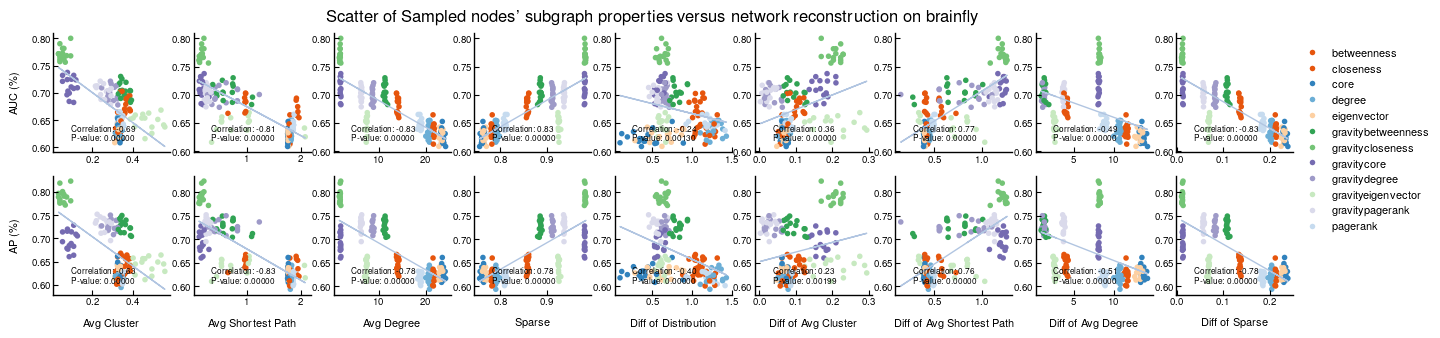

In [32]:
brainfly_tn = pd.read_csv('corrsi\\brainfly_gcn_vae_tn_lp_test.csv')
avg_cluster = brainfly_tn['avg_cluster']
avg_path = brainfly_tn['avg_spl']
avg_degree =  brainfly_tn['avg_degree']
sparse = brainfly_tn['sparsity']
avg_cluster_diff = brainfly_tn['diff_cluster']
avg_path_diff = brainfly_tn['diff_spl']
avg_degree_diff =  brainfly_tn['diff_degree']
sparse_diff = brainfly_tn['diff_sparsity']


diff = brainfly_tn['coeff_diff']
labels = brainfly_tn['measure']
AUC= brainfly_tn['mean_auc']
AP= brainfly_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on brainfly",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\brainfly_tn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\brainfly_tn_corr.pdf',dpi=100)

## CA-HepTh

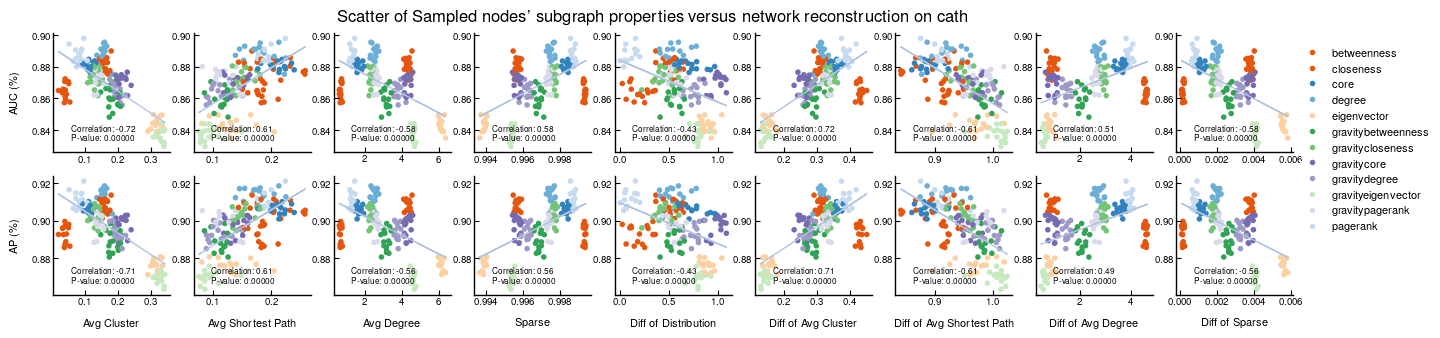

In [33]:
cath_sn = pd.read_csv('corrsi\\cath_gcn_vae_sn_lp_test.csv')
avg_cluster = cath_sn['avg_cluster']
avg_path = cath_sn['avg_spl']
avg_degree =  cath_sn['avg_degree']
sparse = cath_sn['sparsity']
avg_cluster_diff = cath_sn['diff_cluster']
avg_path_diff = cath_sn['diff_spl']
avg_degree_diff =  cath_sn['diff_degree']
sparse_diff = cath_sn['diff_sparsity']


diff = cath_sn['coeff_diff']
labels = cath_sn['measure']
AUC= cath_sn['mean_auc']
AP= cath_sn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on cath",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cath_sn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cath_sn_corr.pdf',dpi=100)

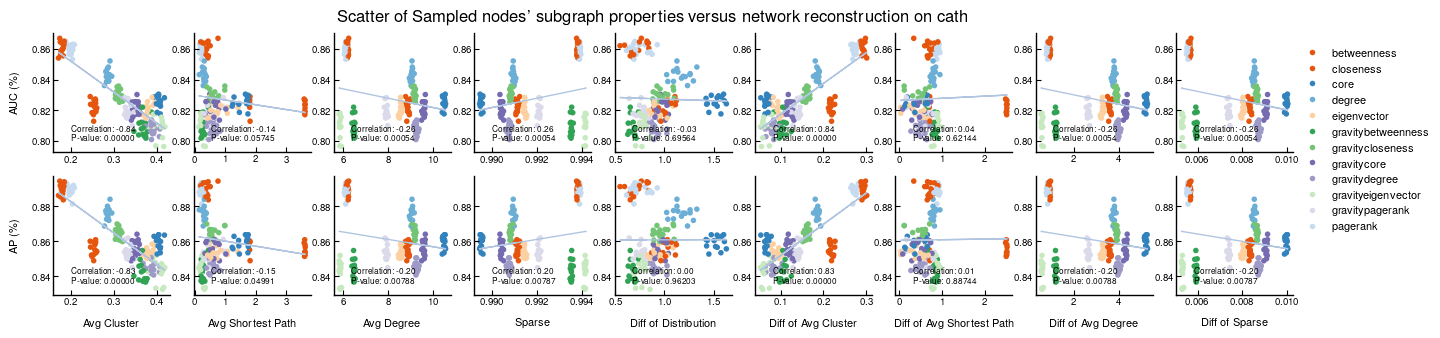

In [34]:
cath_tn = pd.read_csv('corrsi\\cath_gcn_vae_tn_lp_test.csv')
avg_cluster = cath_tn['avg_cluster']
avg_path = cath_tn['avg_spl']
avg_degree =  cath_tn['avg_degree']
sparse = cath_tn['sparsity']
avg_cluster_diff = cath_tn['diff_cluster']
avg_path_diff = cath_tn['diff_spl']
avg_degree_diff =  cath_tn['diff_degree']
sparse_diff = cath_tn['diff_sparsity']


diff = cath_tn['coeff_diff']
labels = cath_tn['measure']
AUC= cath_tn['mean_auc']
AP= cath_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors =   sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on cath",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cath_tn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\cath_tn_corr.pdf',dpi=100)

## WS3000

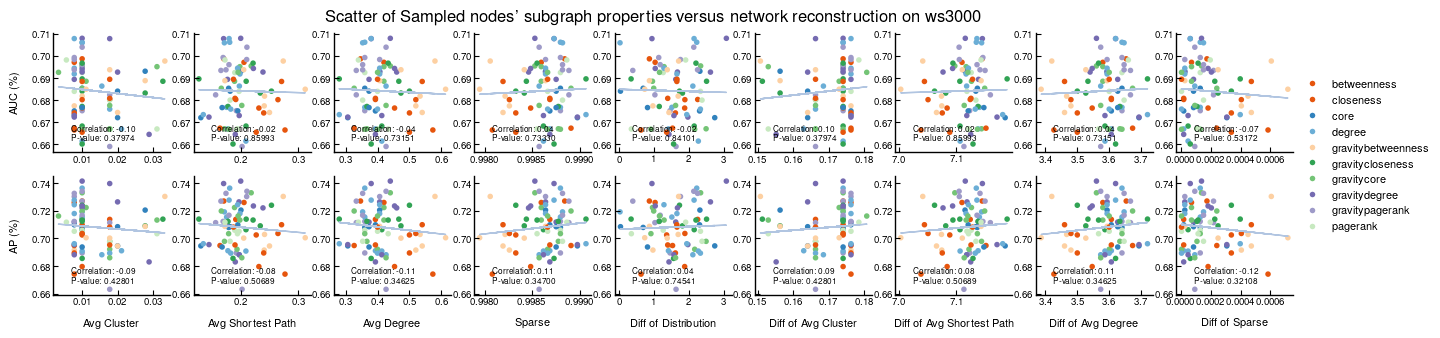

In [35]:
ws3000_sn = pd.read_csv('corrsi\\ws3k_gcn_vae_sn_lp_test.csv')
avg_cluster = ws3000_sn['avg_cluster']
avg_path = ws3000_sn['avg_spl']
avg_degree =  ws3000_sn['avg_degree']
sparse = ws3000_sn['sparsity']
avg_cluster_diff = ws3000_sn['diff_cluster']
avg_path_diff = ws3000_sn['diff_spl']
avg_degree_diff =  ws3000_sn['diff_degree']
sparse_diff = ws3000_sn['diff_sparsity']


diff = ws3000_sn['coeff_diff']
labels = ws3000_sn['measure']
AUC= ws3000_sn['mean_auc']
AP= ws3000_sn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=1)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on ws3000",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ws3000_sn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ws3000_sn_corr.pdf',dpi=100)

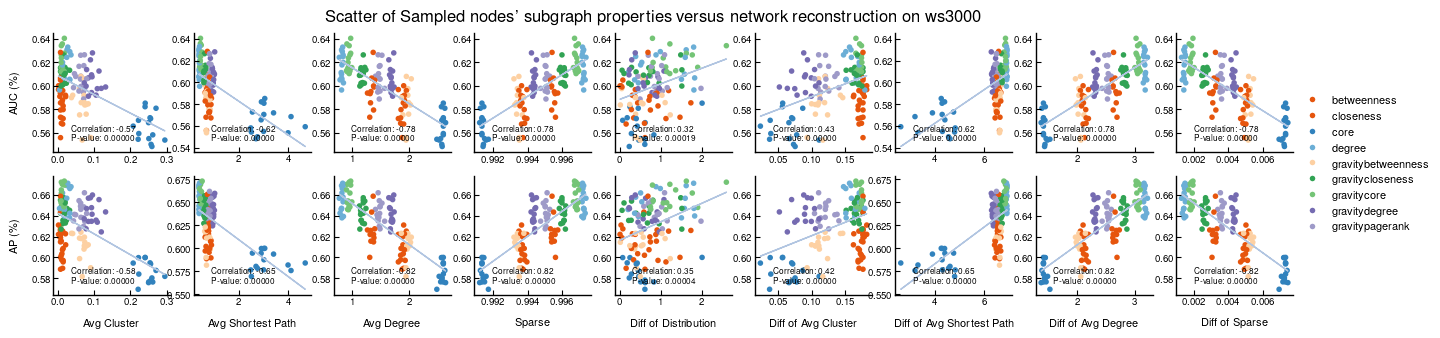

In [36]:
ws3000_tn = pd.read_csv('corrsi\\ws3k_gcn_vae_tn_lp_test.csv')
avg_cluster = ws3000_tn['avg_cluster']
avg_path = ws3000_tn['avg_spl']
avg_degree =  ws3000_tn['avg_degree']
sparse = ws3000_tn['sparsity']
avg_cluster_diff = ws3000_tn['diff_cluster']
avg_path_diff = ws3000_tn['diff_spl']
avg_degree_diff =  ws3000_tn['diff_degree']
sparse_diff = ws3000_tn['diff_sparsity']


diff = ws3000_tn['coeff_diff']
labels = ws3000_tn['measure']
AUC= ws3000_tn['mean_auc']
AP= ws3000_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=1)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on ws3000",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ws3000_tn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ws3000_tn_corr.pdf',dpi=100)

## WS!W

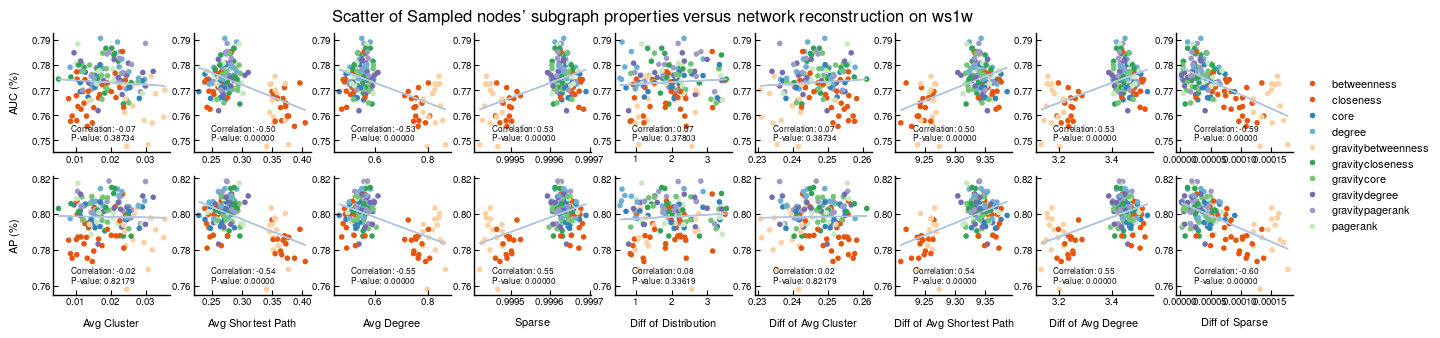

In [37]:
ws1w_sn = pd.read_csv('corrsi\\ws1w_gcn_vae_sn_lp_test.csv')
avg_cluster = ws1w_sn['avg_cluster']
avg_path = ws1w_sn['avg_spl']
avg_degree =  ws1w_sn['avg_degree']
sparse = ws1w_sn['sparsity']
avg_cluster_diff = ws1w_sn['diff_cluster']
avg_path_diff = ws1w_sn['diff_spl']
avg_degree_diff =  ws1w_sn['diff_degree']
sparse_diff = ws1w_sn['diff_sparsity']


diff = ws1w_sn['coeff_diff']
labels = ws1w_sn['measure']
AUC= ws1w_sn['mean_auc']
AP= ws1w_sn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=1)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on ws1w",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ws1w_sn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ws1w_sn_corr.pdf',dpi=100)

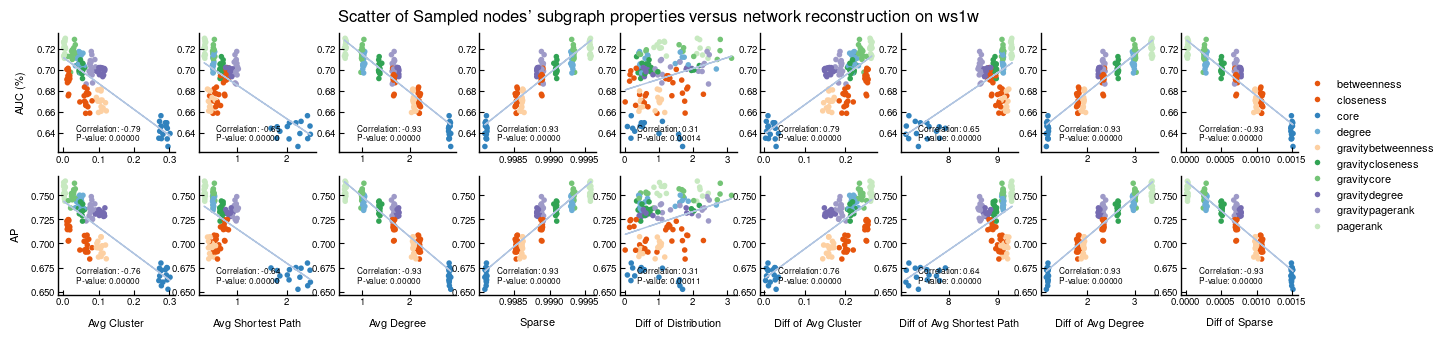

In [39]:
ws1w_tn = pd.read_csv('corrsi\\ws1w_gcn_vae_tn_lp_test.csv')
avg_cluster = ws1w_tn['avg_cluster']
avg_path = ws1w_tn['avg_spl']
avg_degree =  ws1w_tn['avg_degree']
sparse = ws1w_tn['sparsity']
avg_cluster_diff = ws1w_tn['diff_cluster']
avg_path_diff = ws1w_tn['diff_spl']
avg_degree_diff =  ws1w_tn['diff_degree']
sparse_diff = ws1w_tn['diff_sparsity']


diff = ws1w_tn['coeff_diff']
labels = ws1w_tn['measure']
AUC= ws1w_tn['mean_auc']
AP= ws1w_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False) 
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=1)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on ws1w",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ws1w_tn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ws1w_tn_corr.pdf',dpi=100)

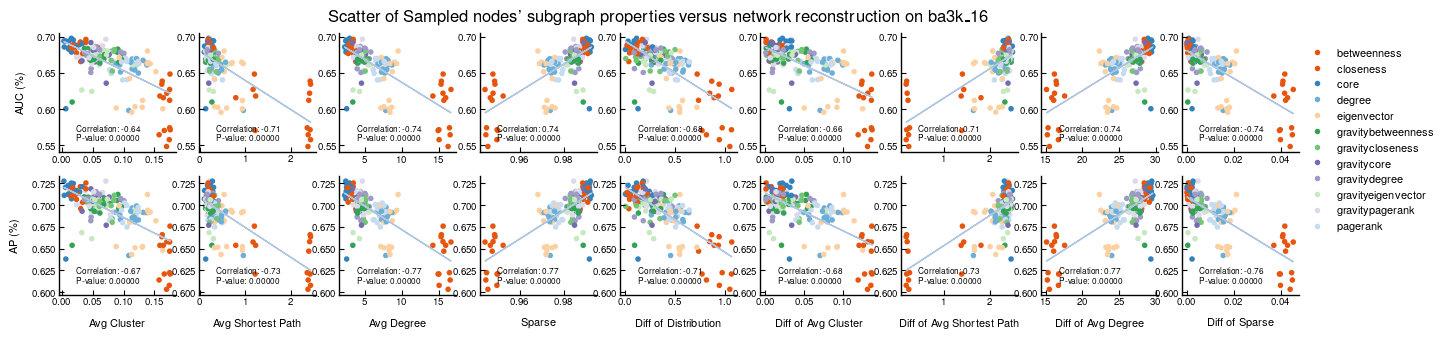

In [40]:
ba3k_16_sn = pd.read_csv('corrsi\\ba3k_16_gcn_vae_sn_lp_test.csv')
avg_cluster = ba3k_16_sn['avg_cluster']
avg_path = ba3k_16_sn['avg_spl']
avg_degree =  ba3k_16_sn['avg_degree']
sparse = ba3k_16_sn['sparsity']
avg_cluster_diff = ba3k_16_sn['diff_cluster']
avg_path_diff = ba3k_16_sn['diff_spl']
avg_degree_diff =  ba3k_16_sn['diff_degree']
sparse_diff = ba3k_16_sn['diff_sparsity']


diff = ba3k_16_sn['coeff_diff']
labels = ba3k_16_sn['measure']
AUC= ba3k_16_sn['mean_auc']
AP= ba3k_16_sn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on ba3k_16",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ba3k_16_sn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ba3k_16_sn_corr.pdf',dpi=100)

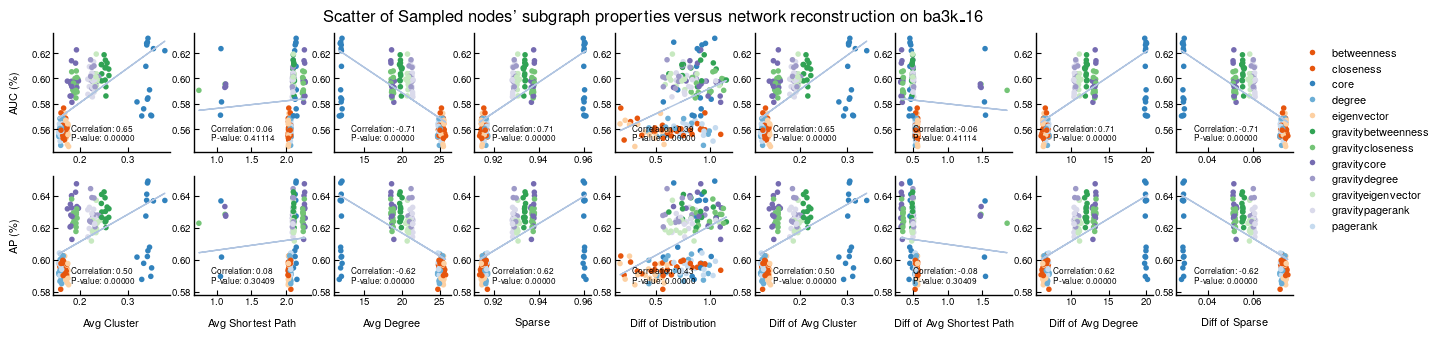

In [41]:
ba3k_16_tn = pd.read_csv('corrsi\\ba3k_16_gcn_vae_tn_lp_test.csv')
avg_cluster = ba3k_16_tn['avg_cluster']
avg_path = ba3k_16_tn['avg_spl']
avg_degree =  ba3k_16_tn['avg_degree']
sparse = ba3k_16_tn['sparsity']
avg_cluster_diff = ba3k_16_tn['diff_cluster']
avg_path_diff = ba3k_16_tn['diff_spl']
avg_degree_diff =  ba3k_16_tn['diff_degree']
sparse_diff = ba3k_16_tn['diff_sparsity']


diff = ba3k_16_tn['coeff_diff']
labels = ba3k_16_tn['measure']
AUC= ba3k_16_tn['mean_auc']
AP= ba3k_16_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 9, figsize=(8, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(data['avg_cluster'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(data['avg_path'], data['AUC'], axes[0, 1], '', '', point_colors)
plot_scatter(data['avg_degree'], data['AUC'], axes[0, 2], '', '', point_colors)
plot_scatter(data['sparse'], data['AUC'], axes[0, 3], '', '', point_colors)


plot_scatter(data['diff'], data['AUC'], axes[0, 4], '', '', point_colors)
plot_scatter(data['avg_cluster_diff'], data['AUC'], axes[0, 5], '', '', point_colors)
plot_scatter(data['avg_path_diff'], data['AUC'], axes[0, 6], '', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AUC'], axes[0, 7], '', '', point_colors)
plot_scatter(data['sparse_diff'], data['AUC'], axes[0, 8], '', '', point_colors)


plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree'], data['AP'], axes[1, 2], 'Avg Degree', '', point_colors)
plot_scatter(data['sparse'], data['AP'], axes[1, 3], 'Sparse', '', point_colors)
plot_scatter(data['diff'], data['AP'], axes[1, 4], 'Diff of Distribution', '', point_colors)

plot_scatter(data['avg_cluster_diff'], data['AP'], axes[1, 5], 'Diff of Avg Cluster', ' ', point_colors)
plot_scatter(data['avg_path_diff'], data['AP'], axes[1, 6], 'Diff of Avg Shortest Path', '', point_colors)
plot_scatter(data['avg_degree_diff'], data['AP'], axes[1, 7], 'Diff of Avg Degree', '', point_colors)
plot_scatter(data['sparse_diff'], data['AP'], axes[1, 8], 'Diff of Sparse', '', point_colors)

# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on ba3k_16",fontsize=6,x=0.5,y=0.95)

plt.show()
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ba3k_16_tn_corr.png',dpi=200)
fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ba3k_16_tn_corr.pdf',dpi=100)

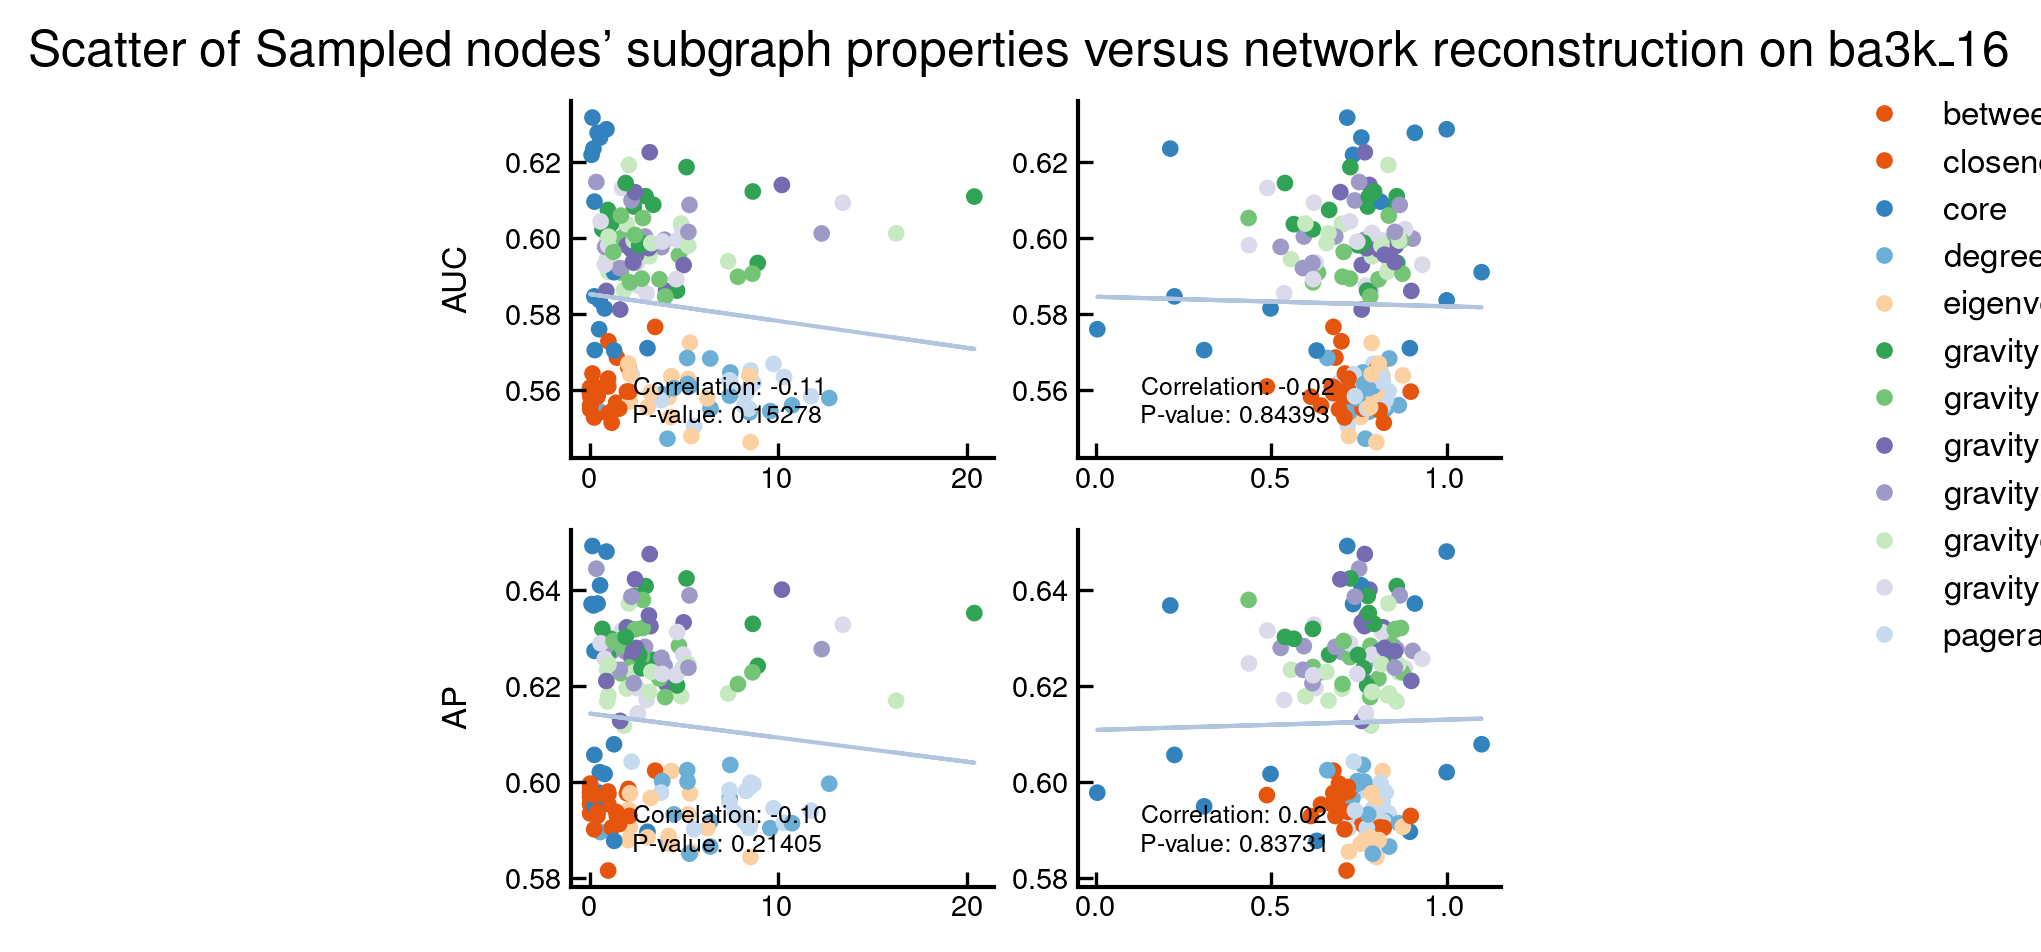

In [12]:
ba3k_16_tn = pd.read_csv('corrsi\\ba3k_16_gcn_vae_tn_lp_test.csv')
avg_cluster = ba3k_16_tn['avg_cluster']
avg_path = ba3k_16_tn['avg_spl']
avg_degree =  ba3k_16_tn['avg_degree']
sparse = ba3k_16_tn['sparsity']
avg_cluster_diff = ba3k_16_tn['diff_cluster']
avg_path_diff = ba3k_16_tn['diff_spl']
avg_degree_diff =  ba3k_16_tn['diff_degree']
sparse_diff = ba3k_16_tn['diff_sparsity']


diff = ba3k_16_tn['coeff_diff']
labels = ba3k_16_tn['measure']
AUC= ba3k_16_tn['mean_auc']
AP= ba3k_16_tn['mean_ap']


# Generate the data frame
data = pd.DataFrame({
    'avg_cluster': avg_cluster, 'avg_path': avg_path, 'avg_degree': avg_degree,'sparse': sparse, 
    'avg_cluster_diff': avg_cluster_diff, 'avg_path_diff': avg_path_diff, 'avg_degree_diff': avg_degree_diff,'sparse_diff': sparse_diff, 
    'diff': diff, 'AUC': AUC, 'AP': AP
})

# Set up color mapping based on labels
unique_labels = np.unique(labels)
colors  = sns.color_palette(['#e6550d', '#e6550d', '#3182bd', '#6baed6', '#fdd0a2', '#31a354', '#74c476', '#756bb1', '#9e9ac8', '#c7e9c0', '#dadaeb', '#c6dbef'])
#sns.color_palette("tab20c", len(unique_labels))
label_to_color = {label: color for label, color in zip(unique_labels, colors)}
point_colors = [label_to_color[label] for label in labels]

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(2, 1.7),dpi=200)

# Helper function to plot each subplot
def plot_scatter(x_data, y_data, ax, xlabel, ylabel, label_col):
    corr, p_value = pearsonr(x_data, y_data)
    rmse = np.sqrt(mean_squared_error(y_data, x_data))
    X = sm.add_constant(x_data)
    model = sm.OLS(y_data, X).fit()
    y_pred = model.predict(X)

    # Scatter plot with color mapping by label
    ax.scatter(x_data, y_data, color=label_col, alpha=1, s=1)
    ax.plot(x_data, y_pred, color='#B1C5E1', lw=0.5)
    ax.text(0.15, 0.18, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=3)
    ax.text(0.15, 0.10, f'P-value: {p_value:.5f}', transform=ax.transAxes, fontsize=3)
    ax.set_xlabel(xlabel, fontsize=4)
    ax.set_ylabel(ylabel, fontsize=4)

# Plot each feature against AUC and AP with color mapping
plot_scatter(ba3k_16_sn['r_L'], data['AUC'], axes[0, 0], '', 'AUC (\%)', point_colors)
plot_scatter(ba3k_16_sn['r_C'], data['AUC'], axes[0, 1], '', '', point_colors)


plot_scatter(ba3k_16_sn['r_L'], data['AP'], axes[1, 0], '', 'AP (\%)', point_colors)
plot_scatter(ba3k_16_sn['r_C'], data['AP'], axes[1, 1], '', '', point_colors)



# plot_scatter(data['avg_cluster'], data['AP'], axes[1, 0], 'Avg Cluster', 'AP (\%)', point_colors)
# plot_scatter(data['avg_path'], data['AP'], axes[1, 1], 'Avg Shortest Path', '', point_colors)


# Customize subplot appearance
for i, ax in enumerate(axes.flat):

    ax.grid(False)
    ax.tick_params(axis='both', labelsize=3.5, which='both', length=1.8, pad=1, width=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)


handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_to_color[label], markersize=3) for label in unique_labels]
legend_labels = [f'{label}' for label in unique_labels]
fig.legend(handles, legend_labels, loc=[0.90,0.3], fontsize=4, ncol=len(unique_labels)/12)
fig.suptitle(r"Scatter of Sampled nodes' subgraph properties versus network reconstruction on ba3k_16",fontsize=6,x=0.5,y=0.95)

plt.show()
# fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ba3k_16_tn_corr.png',dpi=400)
# fig.savefig('C:\\Users\\WENJIA\\Downloads\\papers\\Corr01\\ba3k_16_tn_corr.pdf',dpi=400)